# Pitt Rehab — Keeogo Insole Gait Analysis

End-to-end pipeline for one subject's Control vs Keeogo trials: load the Noraxon CSV, preprocess,
segment gait cycles, pull per-stance features, summarise, and compare.

Insole signals only — CoP, regional pressure, Total % as a GRF surrogate, plus temporal–spatial
parameters. EMG is excluded.

To run on a new subject, swap the two file paths in §2 and Restart & Run All.

## 1. Setup

In [1]:
from __future__ import annotations

import csv
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy import signal

%matplotlib inline
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

## 2. Config

All knobs live here. Swap the two `*_CSV` paths for a new subject, tweak thresholds if needed,
then Restart & Run All.

In [2]:
# ----- File paths ----------------------------------------------------
DATA_DIR    = Path("/Users/twang.jc/Documents/pitt rehab")
CONTROL_CSV = DATA_DIR / "2025-07-11-16-20_control_FS.csv"
KEEOGO_CSV  = DATA_DIR / "2025-07-11-15-57_keeogo_FS01.csv"

# ----- Acquisition --------------------------------------------------
# Confirmed in the CSV metadata; loader overrides if the file says otherwise.
SAMPLING_RATE_HZ = 2000

# ----- Preprocessing filters ----------------------------------------
COP_LOWPASS_HZ   = 20   # CoP x, y
TOTAL_LOWPASS_HZ = 25   # Total % (force surrogate)
LOWPASS_ORDER    = 4    # Butterworth, zero-phase via filtfilt

# ----- Gait event detection -----------------------------------------
# Peak-based: find_peaks on Total %, then walk outward to HS/TO at HS_TO_FRACTION
# of the peak. Robust to baseline drift, which trips up pure threshold-crossing
# (some subjects never fully unload one side between strides).
PEAK_MIN_DISTANCE_S  = 0.40   # cadence floor: < 150 spm
PEAK_PROMINENCE_FRAC = 0.25   # x trace range
HS_TO_FRACTION       = 0.30

# Heel-dominance gate. 0.0 (default) just reports the ratio without gating —
# heel sensors are flaky, and many subjects (esp. with Keeogo) don't heel-strike.
HEEL_DOMINANCE_AT_HS = 0.00

DISCARD_EDGE_STRIDES = 1    # treadmill ramp-up/down
MIN_STANCES          = 5    # per side, for results to be trusted

# ----- Reporting / effect-direction flags ---------------------------
# +1 = bigger is better, −1 = smaller is better, when Keeogo is helping.
EFFECT_DIRECTION = {
    "stance_time_symmetry_index":  -1,   # toward 0
    "forefoot_impulse_pct_s":      +1,
    "second_peak_total_pct":       +1,
    "stride_time_cv_pct":          -1,
    "step_time_cv_pct":            -1,
    "cop_path_length_mm":          +1,   # longer rollover
    "lateral_symmetry_abs_mm":     -1,
    "cadence_steps_per_min":       +1,
    "loading_rate_pct_per_s":      -1,   # smoother loading
}

## 3. Loading Noraxon CSVs

The exporter writes four rows of header before the data:

| Row | Contents |
|-----|----------|
| 1   | Metadata column names |
| 2   | Metadata values |
| 3   | Blank |
| 4   | Data header |
| 5+  | Time series |

Quoting style isn't consistent between trials — the control file quotes strings, the Keeogo
file doesn't — and the metadata row has free-text clinician notes with commas. To dodge that,
we read the first two rows with the stdlib `csv` module (mixed quoting is fine) and the rest
with `pd.read_csv`.

In [3]:
@dataclass
class Trial:
    """A loaded Noraxon trial: time series + metadata + calibration state."""
    name: str
    source: Path
    sample_rate: float
    subject: dict[str, str]
    data: pd.DataFrame
    activity_start_s: float = 0.0
    bw_reference_total_pct: float | None = None


def load_noraxon_csv(path: Path, name: str) -> Trial:
    """Parse a Noraxon MR 4.0 export into a Trial."""
    # Metadata: row 1 = keys, row 2 = values.
    with open(path, newline="") as fh:
        reader = csv.reader(fh)
        meta_keys = next(reader)
        meta_vals = next(reader)
    subject_meta = {
        k.strip(): str(v).strip()
        for k, v in zip(meta_keys, meta_vals)
        if k.strip()
    }

    # Time series: from row 4 onward.
    data = pd.read_csv(path, skiprows=3, header=0)
    data.columns = [c.strip() for c in data.columns]
    for c in data.columns:
        if c not in {"Activity", "Marker"}:
            data[c] = pd.to_numeric(data[c], errors="coerce")

    sample_rate = float(subject_meta.get("frequency", SAMPLING_RATE_HZ))
    return Trial(
        name=name,
        source=path,
        sample_rate=sample_rate,
        subject=subject_meta,
        data=data,
    )

In [4]:
control = load_noraxon_csv(CONTROL_CSV, "control")
keeogo  = load_noraxon_csv(KEEOGO_CSV,  "keeogo")

for t in (control, keeogo):
    dur = len(t.data) / t.sample_rate
    print(f"{t.name:>7}: {len(t.data):>6,} samples @ {t.sample_rate:.0f} Hz "
          f"({dur:.1f} s)  source={t.source.name}")

print()
print("Subject metadata (control):")
for k, v in control.subject.items():
    if v:
        print(f"  {k:>20}: {v}")


control: 32,159 samples @ 2000 Hz (16.1 s)  source=2025-07-11-16-20_control_FS.csv
 keeogo: 47,600 samples @ 2000 Hz (23.8 s)  source=2025-07-11-15-57_keeogo_FS01.csv

Subject metadata (control):
               ﻿"type": record
            begin_time: -1.17100
             frequency: 2000
                 count: 32159
  created with version: Noraxon MR 4.0.22
  exported with version: 4.0.22
             last_name: KEEOGO 34
                   sex: female
      measurement_date: 2025-07-11T16:20:06.864-04:00
           record_name: control_FS


/var/folders/l2/jjll4pcj60qbv59wv706qns00000gn/T/ipykernel_16332/2617234026.py:27: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path, skiprows=3, header=0)


### Column-name helper

Insole columns have long, side-prefixed names like `"LT Insole.Total (%)"`. Everything below
uses `col(side, channel)` instead of the raw strings.

In [5]:
SIDES = ("LT", "RT")

# (side, channel) → column name.
_COLUMN_TEMPLATES = {
    "total":  "{side} Insole.Total (%)",
    "arch":   "{side} Insole.Arch (%)",
    "heel":   "{side} Insole.Heel (%)",
    "hallux": "{side} Insole.Hallux/Toes (%)",
    "met":    "{side} Insole.Met 1/3/5 (%)",
    "cop_x":  "Insole-{side} Insole-Center of pressure-x (mm)",
    "cop_y":  "Insole-{side} Insole-Center of pressure-y (mm)",
}

def col(side: str, channel: str) -> str:
    """Dataframe column name for a (side, channel) pair.

    >>> col("LT", "total")
    'LT Insole.Total (%)'
    """
    if side not in SIDES:
        raise ValueError(f"side must be one of {SIDES}; got {side!r}")
    if channel not in _COLUMN_TEMPLATES:
        raise ValueError(f"unknown channel {channel!r}; "
                         f"valid: {list(_COLUMN_TEMPLATES)}")
    return _COLUMN_TEMPLATES[channel].format(side=side)

## 4. Preprocessing

Three things happen here:

1. **Trim the pre-roll.** Noraxon starts recording while the subject is standing or stepping
   onto the treadmill. We cut everything before the first sample where either foot carries
   ≥ 5 % of body weight and call that `t = 0`.
2. **Low-pass Total % and CoP.** Regional % channels are already smoothed by the manufacturer.
3. **Flag suspect samples** rather than dropping them — Total % over saturation, CoP jumps
   > 50 mm step-to-step (slippage or foot off sensor). Downstream code can mask if it cares.

In [6]:
def _butter_lowpass(x: np.ndarray, cutoff_hz: float, fs: float,
                    order: int = LOWPASS_ORDER) -> np.ndarray:
    """Zero-phase Butterworth low-pass, NaN-tolerant.

    filtfilt chokes on NaN, so we interpolate gaps before filtering and re-mask
    them after. Safe at our cut-offs (≤ 25 Hz) — insole NaN gaps are usually single samples.
    """
    if np.all(np.isnan(x)):
        return x
    nan_mask = np.isnan(x)
    if nan_mask.any():
        idx = np.arange(len(x))
        x = np.where(nan_mask, np.interp(idx, idx[~nan_mask], x[~nan_mask]), x)
    sos = signal.butter(order, cutoff_hz, btype="low", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, x)
    if nan_mask.any():
        y[nan_mask] = np.nan
    return y


def preprocess(trial: Trial) -> Trial:
    """Trim pre-roll, low-pass appropriate channels, add QC flags. Mutates trial.data."""
    df = trial.data.copy()
    fs = trial.sample_rate

    # ---- 1. Activity-window trim ----------------------------------------
    total_l = df[col("LT", "total")].fillna(0).to_numpy()
    total_r = df[col("RT", "total")].fillna(0).to_numpy()
    contact = (total_l > 5) | (total_r > 5)
    if not contact.any():
        raise RuntimeError(f"No foot contact detected anywhere in {trial.name!r}")
    start_idx = int(np.argmax(contact))
    trial.activity_start_s = float(df["time"].iloc[start_idx])
    df = df.iloc[start_idx:].reset_index(drop=True).copy()
    df["time"] = df["time"] - df["time"].iloc[0]

    # ---- 2. Filtering ---------------------------------------------------
    for side in SIDES:
        df[col(side, "total")] = _butter_lowpass(
            df[col(side, "total")].to_numpy(), TOTAL_LOWPASS_HZ, fs
        )
        df[col(side, "cop_x")] = _butter_lowpass(
            df[col(side, "cop_x")].to_numpy(), COP_LOWPASS_HZ, fs
        )
        df[col(side, "cop_y")] = _butter_lowpass(
            df[col(side, "cop_y")].to_numpy(), COP_LOWPASS_HZ, fs
        )

    # ---- 3. QC flag columns --------------------------------------------
    # Total % can hit 180–220 % BW at the loading peak — only > 300 is truly suspect.
    flag_cols = {}
    for side in SIDES:
        total = df[col(side, "total")]
        dx = df[col(side, "cop_x")].diff().abs()
        dy = df[col(side, "cop_y")].diff().abs()
        flag_cols[f"{side}_qc_oversaturated"] = total > 300
        flag_cols[f"{side}_qc_cop_jump"]      = (dx > 50) | (dy > 50)
    df = pd.concat([df, pd.DataFrame(flag_cols, index=df.index)], axis=1)

    trial.data = df
    return trial

In [7]:
preprocess(control)
preprocess(keeogo)

for t in (control, keeogo):
    dur = t.data["time"].iloc[-1]
    n_overload = int(t.data[f"LT_qc_oversaturated"].sum() + t.data[f"RT_qc_oversaturated"].sum())
    n_jump     = int(t.data[f"LT_qc_cop_jump"].sum()      + t.data[f"RT_qc_cop_jump"].sum())
    print(f"{t.name:>7}: activity_start = {t.activity_start_s:+.3f}s  "
          f"duration after trim = {dur:.2f}s  "
          f"oversaturated={n_overload}  cop_jumps={n_jump}")


control: activity_start = -1.171s  duration after trim = 16.08s  oversaturated=0  cop_jumps=0
 keeogo: activity_start = -1.143s  duration after trim = 23.80s  oversaturated=0  cop_jumps=0


## 5. Body-weight calibration (optional)

If a quiet bilateral-stance window exists, we use it as a 100 % BW reference so loading rate
and impulse can be reported against that baseline instead of raw Total %.

Neither existing trial has a marked quiet-stance window, so the function auto-searches for the
first 2 s of low-variability bilateral contact. If nothing qualifies, calibration is skipped
silently and downstream code uses raw Total %. Override via `MANUAL_QUIET_STANCE_WINDOWS`.

In [8]:
# Optional override: {trial_name: (t_start_s, t_end_s)} in trimmed-time seconds.
MANUAL_QUIET_STANCE_WINDOWS: dict[str, tuple[float, float]] = {}


def calibrate_body_weight(trial: Trial,
                          window: tuple[float, float] | None = None,
                          win_s: float = 2.0) -> Trial:
    """Estimate 100 % BW from a quiet bilateral-stance window.

    With ``window`` given, use it. Otherwise slide a ``win_s`` window from the start,
    keep ones where both feet are loaded (> 20 %), and pick the lowest combined SD.
    Skips silently if nothing qualifies.
    """
    df = trial.data
    fs = trial.sample_rate

    if window is not None:
        t0, t1 = window
        sl = (df["time"] >= t0) & (df["time"] <= t1)
        bw = float(df.loc[sl, col("LT", "total")].mean() +
                   df.loc[sl, col("RT", "total")].mean())
    else:
        n_win = int(win_s * fs)
        if len(df) < n_win:
            return trial
        total_l = df[col("LT", "total")].to_numpy()
        total_r = df[col("RT", "total")].to_numpy()
        both_loaded = (total_l > 20) & (total_r > 20)

        best_start, best_score = None, np.inf
        for s in range(0, len(df) - n_win, max(n_win // 4, 1)):
            sl = slice(s, s + n_win)
            if not both_loaded[sl].all():
                continue
            score = float(total_l[sl].std() + total_r[sl].std())
            if score < best_score:
                best_score, best_start = score, s

        if best_start is None:
            return trial
        sl = slice(best_start, best_start + n_win)
        bw = float(total_l[sl].mean() + total_r[sl].mean())

    trial.bw_reference_total_pct = bw
    return trial


for t in (control, keeogo):
    calibrate_body_weight(t, MANUAL_QUIET_STANCE_WINDOWS.get(t.name))
    if t.bw_reference_total_pct is None:
        print(f"{t.name:>7}: no quiet-stance window — metrics stay in raw Total %.")
    else:
        print(f"{t.name:>7}: 100 % BW ≈ {t.bw_reference_total_pct:.1f} % "
              f"(sum of both feet)")

control: 100 % BW ≈ 141.5 % (sum of both feet)
 keeogo: 100 % BW ≈ 139.1 % (sum of both feet)


## 6. Gait cycle segmentation

Peak-based segmentation on each side's Total % trace (more forgiving of baseline drift than
fixed-threshold edge detection):

1. **Stance peaks** via `scipy.signal.find_peaks` with `distance = PEAK_MIN_DISTANCE_S` (cadence
   floor) and `prominence = PEAK_PROMINENCE_FRAC × trace range`. Each peak is mid-stance.
2. **HS / TO** are the points either side of the peak where Total % drops below
   `HS_TO_FRACTION × peak`.
3. **Heel-dominance** (heel load near HS) is reported as a QC stat but, by default, doesn't
   reject events — insole heel sensors are flaky, and many subjects (especially under Keeogo)
   don't heel-strike. Set `HEEL_DOMINANCE_AT_HS > 0` to gate on it.

From the events:

* **Stance** = HS → next TO, same side
* **Stride** = HS → next HS, same side
* **Step** = HS on one side → HS on the other (computed later in §8)

First and last full stride per side are discarded — treadmill ramp-up/down.

In [9]:
@dataclass
class GaitEvents:
    """HS / TO indices for one trial, both sides; indices into trial.data."""
    LT_hs: np.ndarray
    LT_to: np.ndarray
    RT_hs: np.ndarray
    RT_to: np.ndarray

    def stances(self, side: str) -> list[tuple[int, int]]:
        """[(hs_idx, to_idx), ...] for side."""
        hs = getattr(self, f"{side}_hs")
        to = getattr(self, f"{side}_to")
        out: list[tuple[int, int]] = []
        for h in hs:
            after = to[to > h]
            if len(after):
                out.append((int(h), int(after[0])))
        return out

    def strides(self, side: str) -> list[tuple[int, int]]:
        """[(hs_idx, next_hs_idx), ...] for side."""
        hs = getattr(self, f"{side}_hs")
        return [(int(hs[i]), int(hs[i + 1])) for i in range(len(hs) - 1)]


def _edges(x: np.ndarray, threshold: float) -> tuple[np.ndarray, np.ndarray]:
    """Rising / falling crossings of threshold."""
    above = x > threshold
    transitions = np.diff(above.astype(int), prepend=0)
    rising  = np.where(transitions ==  1)[0]
    falling = np.where(transitions == -1)[0]
    return rising, falling


def detect_gait_events(trial: Trial,
                       heel_dominance: float = HEEL_DOMINANCE_AT_HS,
                       ) -> tuple[GaitEvents, dict]:
    """Peak-based HS / TO detection with per-side QC. Returns (events, qc dict).

    Steps: find peaks on Total % → walk outward to HS/TO at HS_TO_FRACTION of
    the peak → drop overlaps → check (and optionally gate on) heel dominance
    in a ±20 ms window around HS → trim DISCARD_EDGE_STRIDES from each end.
    """
    df = trial.data
    fs = trial.sample_rate
    win_n = int(0.02 * fs)  # ±20 ms heel-dominance check window

    events: dict[str, np.ndarray] = {}
    qc: dict = {}

    for side in SIDES:
        total = df[col(side, "total")].fillna(0).to_numpy()
        heel  = df[col(side, "heel")].fillna(0).to_numpy()

        # ---- 1. Peak detection on Total % -------------------------------
        min_dist = int(PEAK_MIN_DISTANCE_S * fs)
        trace_range = float(np.max(total) - np.min(total))
        prom = max(10.0, PEAK_PROMINENCE_FRAC * trace_range)
        peaks, _ = signal.find_peaks(total, distance=min_dist, prominence=prom)

        # ---- 2. HS / TO around each peak --------------------------------
        hs_paired: list[int] = []
        to_paired: list[int] = []
        for p_idx in peaks:
            thr = HS_TO_FRACTION * float(total[p_idx])
            # Walk LEFT from peak to find HS = first sample dropping below thr.
            i = p_idx
            while i > 0 and total[i] > thr:
                i -= 1
            hs = int(i)
            # Walk RIGHT from peak to find TO = first sample dropping below thr.
            j = p_idx
            while j < len(total) - 1 and total[j] > thr:
                j += 1
            to = int(j)
            if to <= hs:
                continue
            hs_paired.append(hs)
            to_paired.append(to)

        # ---- 3. Remove overlaps (TO must precede next HS) ---------------
        dedup_hs: list[int] = []
        dedup_to: list[int] = []
        for h, t in zip(hs_paired, to_paired):
            if dedup_to and h <= dedup_to[-1]:
                continue
            dedup_hs.append(h); dedup_to.append(t)

        # ---- 4. Heel-dominance QC and optional rejection ---------------
        heel_dom_passed = 0
        kept_hs, kept_to = [], []
        for h, t in zip(dedup_hs, dedup_to):
            sl = slice(max(0, h - win_n), min(len(total), h + win_n + 1))
            tot_peak  = float(total[sl].max())
            heel_peak = float(heel[sl].max())
            ratio = heel_peak / tot_peak if tot_peak > 0 else 0.0
            if ratio >= 0.30:                # canonical heel-strike threshold
                heel_dom_passed += 1
            if heel_dominance > 0 and ratio < heel_dominance:
                continue
            kept_hs.append(h); kept_to.append(t)

        # ---- 5. Trim treadmill edge strides ----------------------------
        if len(kept_hs) > 2 * DISCARD_EDGE_STRIDES:
            kept_hs = kept_hs[DISCARD_EDGE_STRIDES:-DISCARD_EDGE_STRIDES]
            kept_to = kept_to[DISCARD_EDGE_STRIDES:-DISCARD_EDGE_STRIDES]

        events[f"{side}_hs"] = np.asarray(kept_hs, dtype=int)
        events[f"{side}_to"] = np.asarray(kept_to, dtype=int)
        qc[f"{side}_n_candidate_hs"]      = len(dedup_hs)
        qc[f"{side}_heel_dominance_frac"] = (heel_dom_passed / len(dedup_hs)
                                             if dedup_hs else float("nan"))

    return GaitEvents(**events), qc

In [10]:
control_events, control_qc = detect_gait_events(control)
keeogo_events,  keeogo_qc  = detect_gait_events(keeogo)

for label, ev, qc in (("control", control_events, control_qc),
                      ("keeogo",  keeogo_events,  keeogo_qc)):
    print(f"{label:>7}: "
          f"LT {len(ev.LT_hs):>3} HS / {len(ev.LT_to):>3} TO   "
          f"RT {len(ev.RT_hs):>3} HS / {len(ev.RT_to):>3} TO")
    for side in SIDES:
        frac = qc[f"{side}_heel_dominance_frac"]
        marker = "" if frac >= 0.5 else "  ⚠ non-heel-striker or weak heel sensor"
        print(f"           {side} heel-dominance: {frac*100:5.1f}% of HS events{marker}")

# Hard gate: warn if any side has fewer than MIN_STANCES.
for label, ev in (("control", control_events), ("keeogo", keeogo_events)):
    for side in SIDES:
        n = len(ev.stances(side))
        if n < MIN_STANCES:
            print(f"  ⚠  {label} {side}: only {n} clean stances "
                  f"(< MIN_STANCES={MIN_STANCES}). "
                  f"Results for this side will be unreliable.")


control: LT  10 HS /  10 TO   RT   9 HS /   9 TO
           LT heel-dominance: 100.0% of HS events
           RT heel-dominance:   0.0% of HS events  ⚠ non-heel-striker or weak heel sensor
 keeogo: LT  11 HS /  11 TO   RT  11 HS /  11 TO
           LT heel-dominance:   0.0% of HS events  ⚠ non-heel-striker or weak heel sensor
           RT heel-dominance:   0.0% of HS events  ⚠ non-heel-striker or weak heel sensor


### Visual QC

Eyeball check: HS triangles should sit at the leading edge of each Total % bump, TO at the
trailing edge, and left/right should interleave cleanly.

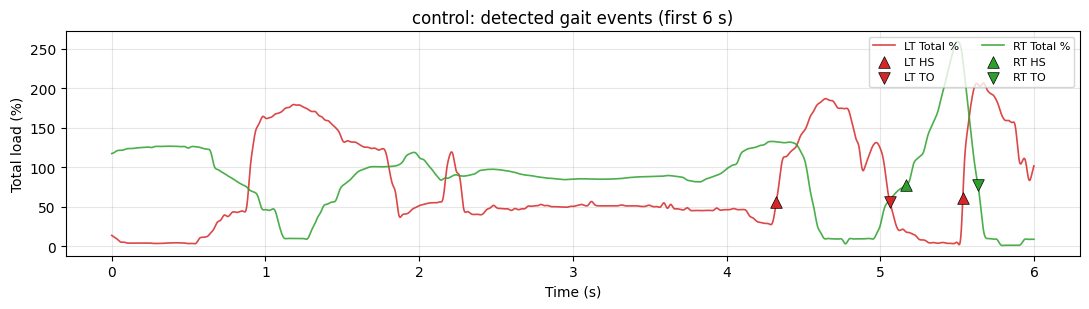

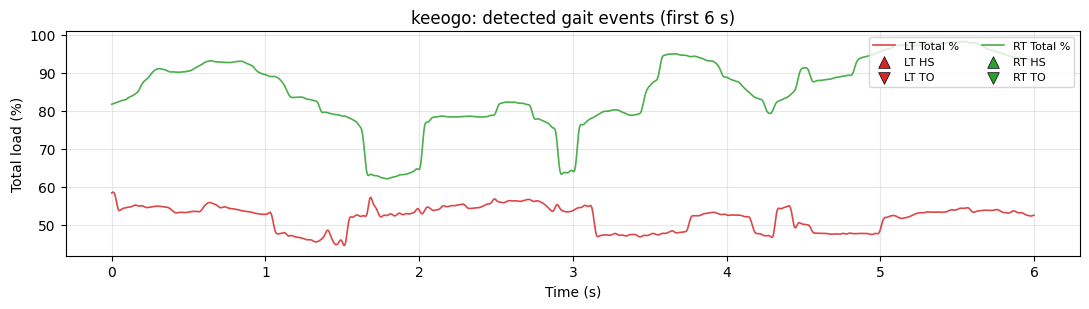

In [11]:
def plot_gait_events(trial: Trial, events: GaitEvents,
                     max_seconds: float = 6.0) -> None:
    """Overlay HS (▲) and TO (▼) on each side's Total % trace."""
    df = trial.data
    t = df["time"].to_numpy()
    n_max = int(max_seconds * trial.sample_rate)
    fig, ax = plt.subplots(figsize=(11, 3.2))
    for side, color in (("LT", "tab:red"), ("RT", "tab:green")):
        ax.plot(t[:n_max], df[col(side, "total")].to_numpy()[:n_max],
                color=color, label=f"{side} Total %", alpha=0.85, lw=1.2)
        hs = getattr(events, f"{side}_hs")
        to_ = getattr(events, f"{side}_to")
        hs = hs[hs < n_max]
        to_ = to_[to_ < n_max]
        ax.scatter(t[hs],  df[col(side, "total")].to_numpy()[hs],
                   marker="^", color=color, s=70, edgecolor="black",
                   linewidth=0.5, label=f"{side} HS", zorder=3)
        ax.scatter(t[to_], df[col(side, "total")].to_numpy()[to_],
                   marker="v", color=color, s=70, edgecolor="black",
                   linewidth=0.5, label=f"{side} TO", zorder=3)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Total load (%)")
    ax.set_title(f"{trial.name}: detected gait events (first {max_seconds:.0f} s)")
    ax.legend(loc="upper right", ncols=2, fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


plot_gait_events(control, control_events)
plot_gait_events(keeogo,  keeogo_events)


## 7. Per-stance feature extraction

For each (HS, TO) pair, one row of features:

* **CoP** — path length, mean x / y, x / y range, regression angle (positive = lateral
  progression, per PDF p. 24).
* **Regional pressure** — peak %, impulse % · s, start / peak-time / end as % of stance,
  for Heel, Arch, Met 1/3/5, Hallux/Toes.
* **M-curve** — first peak (loading, 0–30 % stance), mid trough (30–55 %), second peak
  (push-off, 45–80 %), trough-to-peak ratio, loading and unloading rates.
* **Timing** — stance duration (s) and stance as % of the same stride.

The trial summary in §8 aggregates over these.

In [12]:
def _cop_regression_angle_deg(x: np.ndarray, y: np.ndarray) -> float:
    """CoP regression-line angle (deg) vs walking direction.

    Per PDF p. 24: positive = lateral, negative = medial. Slope from least
    squares ``x = a·y + b``; defensive about NaN and rank-deficient inputs
    (e.g. swing-phase samples where CoP collapses to a point).
    """
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 3:
        return np.nan
    x_c, y_c = x[mask], y[mask]
    if np.ptp(y_c) == 0:
        return np.nan
    try:
        slope, _ = np.polyfit(y_c, x_c, 1)
    except np.linalg.LinAlgError:
        return np.nan
    return float(np.degrees(np.arctan(slope)))


def _pct_stance(local_idx: int, stance_len: int) -> float:
    """Within-stance index → % of stance (0–100)."""
    return float(local_idx / max(stance_len - 1, 1) * 100)


def stance_features(trial: Trial, events: GaitEvents, side: str) -> pd.DataFrame:
    """Per-stance feature dataframe for one side."""
    df = trial.data
    fs = trial.sample_rate
    stance_pairs = events.stances(side)
    if not stance_pairs:
        return pd.DataFrame()

    # Pre-fetch channels for tight inner-loop access.
    total  = df[col(side, "total")].to_numpy()
    heel   = df[col(side, "heel")].to_numpy()
    arch   = df[col(side, "arch")].to_numpy()
    met    = df[col(side, "met")].to_numpy()
    hallux = df[col(side, "hallux")].to_numpy()
    copx   = df[col(side, "cop_x")].to_numpy()
    copy   = df[col(side, "cop_y")].to_numpy()
    time   = df["time"].to_numpy()

    stride_pairs = events.strides(side)
    stride_dur = {hs: float(time[next_hs] - time[hs])
                  for hs, next_hs in stride_pairs}

    rows: list[dict] = []
    for hs, to_ in stance_pairs:
        sl = slice(hs, to_ + 1)
        n  = to_ - hs + 1
        if n < 5:        # implausibly short → skip
            continue

        stance_s = float(time[to_] - time[hs])
        stride_s = stride_dur.get(hs, np.nan)

        # ---- CoP ---------------------------------------------------------
        x, y = copx[sl], copy[sl]
        cop_path = float(np.nansum(np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)))

        # ---- Region peaks, impulses, timings ----------------------------
        region_feats: dict[str, float] = {}
        for rname, rdata in (("heel", heel), ("arch", arch),
                             ("met",  met),  ("hallux", hallux)):
            rseg = rdata[sl]
            peak = float(np.nanmax(rseg)) if rseg.size else np.nan
            impulse = float(np.trapezoid(rseg, dx=1.0 / fs))
            if peak > 0:
                peak_idx = int(np.nanargmax(rseg))
                above = rseg >= 0.05 * peak
                if above.any():
                    start_pct = _pct_stance(int(np.argmax(above)), n)
                    end_pct   = _pct_stance(n - 1 - int(np.argmax(above[::-1])), n)
                else:
                    start_pct = end_pct = np.nan
                peak_time_pct = _pct_stance(peak_idx, n)
            else:
                start_pct = end_pct = peak_time_pct = np.nan

            region_feats[f"{rname}_peak_pct"]      = peak
            region_feats[f"{rname}_impulse_pct_s"] = impulse
            region_feats[f"{rname}_peak_time_pct"] = peak_time_pct
            region_feats[f"{rname}_start_pct"]     = start_pct
            region_feats[f"{rname}_end_pct"]       = end_pct

        # ---- M-curve (Total %) ------------------------------------------
        tseg = total[sl]
        first_w  = slice(0,                max(int(0.30 * n), 3))
        mid_w    = slice(int(0.30 * n),    int(0.55 * n) + 1)
        second_w = slice(int(0.45 * n),    min(int(0.80 * n) + 1, n))

        first_peak  = float(np.nanmax(tseg[first_w]))  if tseg[first_w].size  else np.nan
        mid_trough  = float(np.nanmin(tseg[mid_w]))    if tseg[mid_w].size    else np.nan
        second_peak = float(np.nanmax(tseg[second_w])) if tseg[second_w].size else np.nan
        first_peak_local = (int(np.nanargmax(tseg[first_w]))  + first_w.start)  if tseg[first_w].size  else None
        second_peak_local = (int(np.nanargmax(tseg[second_w])) + second_w.start) if tseg[second_w].size else None

        trough_ratio = (mid_trough / first_peak) if (first_peak and not np.isnan(mid_trough)) else np.nan

        loading_rate = (first_peak / (first_peak_local / fs)
                        if first_peak_local and first_peak_local > 0 else np.nan)
        unloading_rate = (second_peak / ((n - 1 - second_peak_local) / fs)
                          if second_peak_local is not None and (n - 1 - second_peak_local) > 0 else np.nan)

        rows.append({
            "side":             side,
            "hs_idx":           hs,
            "to_idx":           to_,
            "hs_time_s":        float(time[hs]),
            "stance_duration_s":  stance_s,
            "stride_duration_s":  stride_s,
            "stance_pct_of_stride": (stance_s / stride_s * 100) if stride_s else np.nan,
            "cop_path_length_mm":     cop_path,
            "cop_x_mean_mm":          float(np.nanmean(x)),
            "cop_y_mean_mm":          float(np.nanmean(y)),
            "cop_x_range_mm":         float(np.nanmax(x) - np.nanmin(x)),
            "cop_y_range_mm":         float(np.nanmax(y) - np.nanmin(y)),
            "cop_regression_angle_deg": _cop_regression_angle_deg(x, y),
            **region_feats,
            "first_peak_total_pct":      first_peak,
            "second_peak_total_pct":     second_peak,
            "mid_trough_total_pct":      mid_trough,
            "trough_to_peak_ratio":      trough_ratio,
            "loading_rate_pct_per_s":    loading_rate,
            "unloading_rate_pct_per_s":  unloading_rate,
        })
    return pd.DataFrame(rows)


def all_stance_features(trial: Trial, events: GaitEvents) -> pd.DataFrame:
    """Concatenate per-side stance features."""
    parts = [stance_features(trial, events, s) for s in SIDES]
    return pd.concat(parts, ignore_index=True)

In [13]:
control_stances = all_stance_features(control, control_events)
keeogo_stances  = all_stance_features(keeogo,  keeogo_events)

def _summarise(df: pd.DataFrame, label: str) -> None:
    print(f"{label}: per-stance features ({len(df)} stances)")
    if df.empty or df.select_dtypes('number').empty:
        print("  (no rows to describe)")
        return
    display(df.select_dtypes('number').describe().T[["count", "mean", "std", "min", "max"]]
              .round(2).head(14))

_summarise(control_stances, "Control")
print()
_summarise(keeogo_stances,  "Keeogo")


Control: per-stance features (19 stances)


,count,mean,std,min,max
hs_idx,19.0,18257.74,5708.60,8647.00,27320.00
to_idx,19.0,19368.74,5714.43,10125.00,28589.00
hs_time_s,19.0,9.13,2.85,4.32,13.66
stance_duration_s,19.0,0.56,0.06,0.47,0.74
stride_duration_s,17.0,1.02,0.05,0.98,1.21
stance_pct_of_stride,17.0,53.77,4.26,45.34,60.90
cop_path_length_mm,19.0,123.12,73.56,42.62,210.26
cop_x_mean_mm,19.0,51.84,0.25,51.42,52.30
cop_y_mean_mm,19.0,159.10,17.57,127.75,176.41
cop_x_range_mm,19.0,5.12,3.76,1.23,9.26



Keeogo: per-stance features (22 stances)


,count,mean,std,min,max
hs_idx,22.0,31445.95,6264.48,21441.00,41916.00
to_idx,22.0,32425.95,6401.92,22288.00,43482.00
hs_time_s,22.0,15.72,3.13,10.72,20.96
stance_duration_s,22.0,0.49,0.09,0.39,0.78
stride_duration_s,20.0,0.97,0.05,0.87,1.12
stance_pct_of_stride,20.0,47.89,2.68,44.08,54.56
cop_path_length_mm,22.0,60.48,19.47,34.74,94.43
cop_x_mean_mm,22.0,52.08,0.37,51.63,52.94
cop_y_mean_mm,22.0,179.77,9.89,163.64,193.34
cop_x_range_mm,22.0,5.18,3.57,1.52,9.63


## 8. Trial-level summary

Roll each per-stance dataframe up to one row of metrics per side, plus bilateral measures
(symmetry indices, CVs). These are what §9 compares across conditions.

In [14]:
def _sym_index(left: float, right: float) -> float:
    """Symmetry Index = (L − R) / (½ (L + R)) × 100. Signed; positive = L larger."""
    if np.isnan(left) or np.isnan(right):
        return np.nan
    denom = 0.5 * (left + right)
    return float((left - right) / denom * 100) if denom else np.nan


def _cv_pct(series: pd.Series) -> float:
    """Coefficient of variation (%)."""
    s = series.dropna()
    if len(s) < 2 or s.mean() == 0:
        return np.nan
    return float(s.std(ddof=1) / s.mean() * 100)


# Features reported side-wise (mean and SD).
_PER_SIDE_FEATURES = (
    "stance_duration_s", "stride_duration_s", "stance_pct_of_stride",
    "cop_path_length_mm", "cop_regression_angle_deg",
    "cop_x_mean_mm", "cop_y_mean_mm",
    "heel_peak_pct", "arch_peak_pct", "met_peak_pct", "hallux_peak_pct",
    "heel_impulse_pct_s", "met_impulse_pct_s", "hallux_impulse_pct_s",
    "first_peak_total_pct", "second_peak_total_pct",
    "trough_to_peak_ratio",
    "loading_rate_pct_per_s", "unloading_rate_pct_per_s",
)


def trial_summary(stances: pd.DataFrame, trial: Trial) -> dict[str, object]:
    """Reduce per-stance dataframe to one trial-level summary dict."""
    out: dict[str, object] = {"trial": trial.name}

    # ---- Per-side means / SDs ------------------------------------------
    for side in SIDES:
        s = stances[stances["side"] == side]
        out[f"{side}_n_stances"] = int(len(s))
        for f in _PER_SIDE_FEATURES:
            vals = s[f].to_numpy() if f in s.columns else np.array([])
            vals = vals[~np.isnan(vals)]
            out[f"{side}_{f}_mean"] = float(vals.mean()) if vals.size      else np.nan
            out[f"{side}_{f}_sd"]   = float(vals.std(ddof=1)) if vals.size > 1 else np.nan

    left  = stances[stances["side"] == "LT"]
    right = stances[stances["side"] == "RT"]

    # ---- Bilateral / symmetry metrics ----------------------------------
    out["stance_time_symmetry_index"] = _sym_index(
        left["stance_duration_s"].mean(), right["stance_duration_s"].mean()
    )

    out["stride_time_cv_pct"] = _cv_pct(
        pd.concat([left["stride_duration_s"], right["stride_duration_s"]])
    )

    # Step time = consecutive contralateral HS interval.
    all_hs = pd.concat([
        left[["hs_time_s"]].assign(side="LT"),
        right[["hs_time_s"]].assign(side="RT"),
    ]).sort_values("hs_time_s")
    step_times = all_hs["hs_time_s"].diff().dropna()
    out["step_time_mean_s"]      = float(step_times.mean()) if len(step_times) else np.nan
    out["step_time_cv_pct"]      = _cv_pct(step_times)
    out["cadence_steps_per_min"] = (60.0 / out["step_time_mean_s"]
                                    if out["step_time_mean_s"] else np.nan)

    # Lateral symmetry from mean CoP-x difference.
    out["lateral_symmetry_mm"]     = float(left["cop_x_mean_mm"].mean() - right["cop_x_mean_mm"].mean())
    out["lateral_symmetry_abs_mm"] = abs(out["lateral_symmetry_mm"])

    # Gait-line symmetry % (Jeleń et al. — PDF p. 20).
    lpath, rpath = left["cop_path_length_mm"].mean(), right["cop_path_length_mm"].mean()
    if not (np.isnan(lpath) or np.isnan(rpath)) and (lpath + rpath) > 0:
        out["gait_line_symmetry_pct"] = abs(lpath - rpath) / (0.5 * (lpath + rpath)) * 100
    else:
        out["gait_line_symmetry_pct"] = np.nan

    # Bilateral mean CoP path (used as an effect-flagged metric).
    out["cop_path_length_mm"] = float(np.nanmean([lpath, rpath]))

    # Forefoot impulse (met + hallux), averaged across sides — % · s.
    out["forefoot_impulse_pct_s"] = float(np.nanmean([
        (left["met_impulse_pct_s"]  + left["hallux_impulse_pct_s"]).mean(),
        (right["met_impulse_pct_s"] + right["hallux_impulse_pct_s"]).mean(),
    ]))

    # Bilateral mean push-off peak and loading rate (so the comparison flags can read them).
    out["second_peak_total_pct"]  = float(np.nanmean([
        left["second_peak_total_pct"].mean(),
        right["second_peak_total_pct"].mean(),
    ]))
    out["loading_rate_pct_per_s"] = float(np.nanmean([
        left["loading_rate_pct_per_s"].mean(),
        right["loading_rate_pct_per_s"].mean(),
    ]))

    return out


control_summary = trial_summary(control_stances, control)
keeogo_summary  = trial_summary(keeogo_stances,  keeogo)

pd.DataFrame([control_summary, keeogo_summary]).set_index("trial").T.round(3)

trial,control,keeogo
LT_n_stances,10.000,11.000
LT_stance_duration_s_mean,0.597,0.511
LT_stance_duration_s_sd,0.055,0.104
LT_stride_duration_s_mean,1.037,0.978
LT_stride_duration_s_sd,0.070,0.063
...,...,...
gait_line_symmetry_pct,118.527,52.031
cop_path_length_mm,119.398,60.482
forefoot_impulse_pct_s,55.708,52.099
second_peak_total_pct,207.370,211.699


## 9. Within-subject Control vs Keeogo

For each summary metric: paired difference (Keeogo − Control), % change, and — for
High-priority metrics in the Parameters List — a flag for whether Keeogo moved the metric
in the expected direction. Metrics outside `EFFECT_DIRECTION` are still shown, just unflagged.

In [15]:
def paired_comparison(control_sum: dict, keeogo_sum: dict,
                      direction: dict[str, int] = EFFECT_DIRECTION) -> pd.DataFrame:
    """Tidy comparison dataframe: metric × {control, keeogo, delta, %, flag}."""
    rows = []
    for key in sorted(set(control_sum) | set(keeogo_sum)):
        if key == "trial":
            continue
        c = control_sum.get(key, np.nan)
        k = keeogo_sum.get(key, np.nan)
        if not (isinstance(c, (int, float, np.floating)) and
                isinstance(k, (int, float, np.floating))):
            continue
        if np.isnan(c) or np.isnan(k):
            rows.append({"metric": key, "control": c, "keeogo": k,
                         "delta": np.nan, "pct_change": np.nan,
                         "direction_flag": ""})
            continue
        delta = k - c
        pct   = (delta / c * 100) if c not in (0, np.nan) else np.nan
        flag  = ""
        if key in direction:
            flag = "✓ expected" if direction[key] * delta > 0 else \
                   "✗ opposite" if direction[key] * delta < 0 else ""
        rows.append({"metric": key, "control": c, "keeogo": k,
                     "delta": delta, "pct_change": pct,
                     "direction_flag": flag})
    return pd.DataFrame(rows)


comparison = paired_comparison(control_summary, keeogo_summary)

# Flagged metrics first, then the rest alphabetically.
flagged   = comparison[comparison["metric"].isin(EFFECT_DIRECTION)].copy()
flagged   = flagged.set_index("metric").reindex(list(EFFECT_DIRECTION)).reset_index()
unflagged = comparison[~comparison["metric"].isin(EFFECT_DIRECTION)].sort_values("metric")
comparison_view = pd.concat([flagged, unflagged], ignore_index=True)

# Pretty number formatting; falls back to a rounded df if jinja2 isn't around.
try:
    comparison_styled = comparison_view.style.format({
        "control":    "{:.3f}",
        "keeogo":     "{:.3f}",
        "delta":      "{:+.3f}",
        "pct_change": "{:+.1f}%",
    }, na_rep="—")
    display(comparison_styled)
except (AttributeError, ImportError):
    display(comparison_view.round(3))

,metric,control,keeogo,delta,pct_change,direction_flag
0,stance_time_symmetry_index,15.703,8.571,-7.132,-45.4%,✓ expected
1,forefoot_impulse_pct_s,55.708,52.099,-3.610,-6.5%,✗ opposite
2,second_peak_total_pct,207.370,211.699,+4.328,+2.1%,✓ expected
3,stride_time_cv_pct,5.283,5.443,+0.160,+3.0%,✗ opposite
4,step_time_cv_pct,23.488,9.195,-14.293,-60.9%,✓ expected
5,cop_path_length_mm,119.398,60.482,-58.916,-49.3%,✗ opposite
6,lateral_symmetry_abs_mm,0.089,0.418,+0.329,+369.7%,✗ opposite
7,cadence_steps_per_min,115.675,123.077,+7.402,+6.4%,✓ expected
8,loading_rate_pct_per_s,1098.525,691.607,-406.918,-37.0%,✓ expected
9,LT_arch_peak_pct_mean,2.762,1.254,-1.509,-54.6%,


## 10. Per-subject report figure

Four panels, Control vs Keeogo overlaid:

* **(a)** CoP gait lines — every stance, both sides, drawn faintly.
* **(b)** Mean Total % M-curve, resampled to 0–100 % stance, per side.
* **(c)** Regional peak %, grouped bar (Heel / Arch / Met / Hallux).
* **(d)** Headline metric table with directional flags.

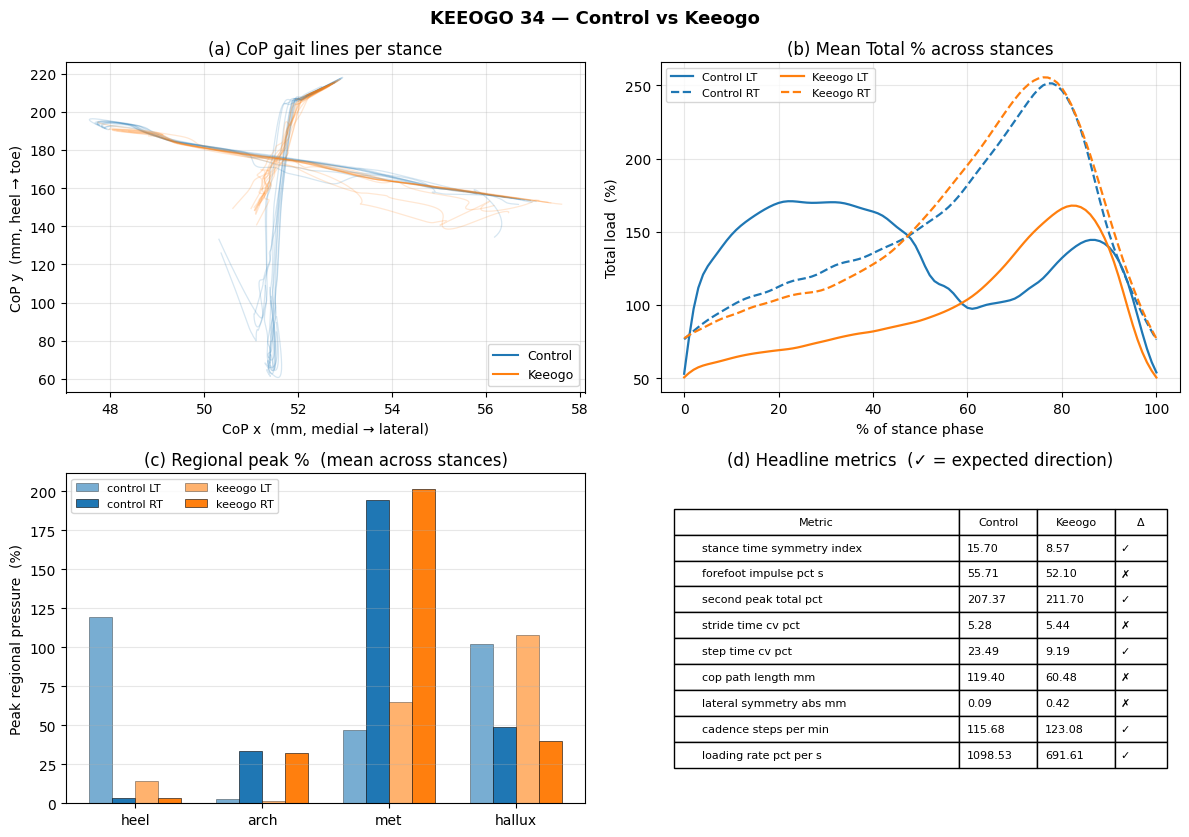

In [16]:
def _stance_normalised_mean(stances: pd.DataFrame, trial: Trial,
                            side: str, channel: str,
                            n_points: int = 101) -> np.ndarray:
    """Resample each stance of a channel to 0–100 % stance, return the mean."""
    df = trial.data
    series = df[col(side, channel)].to_numpy()
    curves: list[np.ndarray] = []
    for _, row in stances[stances["side"] == side].iterrows():
        s = slice(int(row["hs_idx"]), int(row["to_idx"]) + 1)
        seg = series[s]
        if len(seg) < 3:
            continue
        xp = np.linspace(0, 100, len(seg))
        curves.append(np.interp(np.linspace(0, 100, n_points), xp, seg))
    return np.nanmean(np.vstack(curves), axis=0) if curves else np.full(n_points, np.nan)


def report_figure(control_trial: Trial, control_stances: pd.DataFrame,
                  keeogo_trial: Trial, keeogo_stances: pd.DataFrame,
                  control_sum: dict, keeogo_sum: dict) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

    # ---- (a) CoP gait lines, both sides, both conditions ---------------
    ax = axes[0, 0]
    for trial, stances, color, label in (
        (control_trial, control_stances, "tab:blue",   "Control"),
        (keeogo_trial,  keeogo_stances,  "tab:orange", "Keeogo"),
    ):
        df = trial.data
        for side in SIDES:
            for _, row in stances[stances["side"] == side].iterrows():
                s = slice(int(row["hs_idx"]), int(row["to_idx"]) + 1)
                ax.plot(df[col(side, "cop_x")].iloc[s],
                        df[col(side, "cop_y")].iloc[s],
                        color=color, alpha=0.18, lw=0.9)
    ax.set_xlabel("CoP x  (mm, medial → lateral)")
    ax.set_ylabel("CoP y  (mm, heel → toe)")
    ax.set_title("(a) CoP gait lines per stance")
    ax.legend(handles=[
        Line2D([0], [0], color="tab:blue",   label="Control"),
        Line2D([0], [0], color="tab:orange", label="Keeogo"),
    ], loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

    # ---- (b) Total % M-curve, mean across stances ----------------------
    ax = axes[0, 1]
    pct = np.linspace(0, 100, 101)
    for trial, stances, color, label in (
        (control_trial, control_stances, "tab:blue",   "Control"),
        (keeogo_trial,  keeogo_stances,  "tab:orange", "Keeogo"),
    ):
        for side, ls in (("LT", "-"), ("RT", "--")):
            curve = _stance_normalised_mean(stances, trial, side, "total")
            ax.plot(pct, curve, color=color, ls=ls, lw=1.6,
                    label=f"{label} {side}")
    ax.set_xlabel("% of stance phase")
    ax.set_ylabel("Total load  (%)")
    ax.set_title("(b) Mean Total % across stances")
    ax.legend(fontsize=8, ncols=2)
    ax.grid(alpha=0.3)

    # ---- (c) Regional peak %, grouped bar ------------------------------
    ax = axes[1, 0]
    regions = ["heel", "arch", "met", "hallux"]
    width = 0.18
    xpos = np.arange(len(regions))
    bars = [
        (control_trial.name, control_stances, "tab:blue",   "LT", -1.5),
        (control_trial.name, control_stances, "tab:blue",   "RT", -0.5),
        (keeogo_trial.name,  keeogo_stances,  "tab:orange", "LT", +0.5),
        (keeogo_trial.name,  keeogo_stances,  "tab:orange", "RT", +1.5),
    ]
    for label, stances, color, side, off in bars:
        s = stances[stances["side"] == side]
        means = [s[f"{r}_peak_pct"].mean() for r in regions]
        ax.bar(xpos + off * width, means, width,
               label=f"{label} {side}",
               color=color, alpha=(0.6 if side == "LT" else 1.0),
               edgecolor="black", linewidth=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(regions)
    ax.set_ylabel("Peak regional pressure  (%)")
    ax.set_title("(c) Regional peak %  (mean across stances)")
    ax.legend(fontsize=8, ncols=2)
    ax.grid(alpha=0.3, axis="y")

    # ---- (d) Headline metrics table ------------------------------------
    ax = axes[1, 1]
    ax.axis("off")
    headline_keys = list(EFFECT_DIRECTION)
    table_rows = []
    for key in headline_keys:
        c = control_sum.get(key, np.nan)
        k = keeogo_sum.get(key,  np.nan)
        if np.isnan(c) or np.isnan(k):
            flag = "—"
        else:
            flag = "✓" if EFFECT_DIRECTION[key] * (k - c) > 0 else "✗"
        c_str = f"{c:.2f}" if not np.isnan(c) else "—"
        k_str = f"{k:.2f}" if not np.isnan(k) else "—"
        table_rows.append([key.replace("_", " "), c_str, k_str, flag])
    tbl = ax.table(cellText=table_rows,
                   colLabels=["Metric", "Control", "Keeogo", "Δ"],
                   loc="center", cellLoc="left",
                   colWidths=[0.55, 0.15, 0.15, 0.10])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    ax.set_title("(d) Headline metrics  (✓ = expected direction)")

    subject = control_trial.subject.get("last_name") or "subject"
    fig.suptitle(f"{subject} — Control vs Keeogo",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


report_figure(control, control_stances,
              keeogo,  keeogo_stances,
              control_summary, keeogo_summary)

---

## What's next

Steps 1–6 of the guideline — load → preprocess → calibrate → segment → per-stance features →
summary → paired comparison + report figure. Once event detection looks right on this first
pair, the pipeline runs unchanged on every other subject: swap paths in §2, Restart & Run All.

Intentionally not implemented:

* **EMG** — excluded
* **Static-balance metrics** — need a marked quiet-stance segment in the protocol (guideline §5.6).
* **Cohort-level statistics** (n ≈ 10) — start once you have ≥ 6 subjects (guideline §7).
* **KAM, KAI, GPS, GVS** — require IMU / kinematic data + body mass (guideline §9).